In [1]:
%%capture
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../utils')

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from reporting import performance_report
from metrics import get_annualized_mean_return, get_drawdown, get_rolling_correlation
from plotting import set_date_ticks
from optimization import get_portfolio_stats, solve_min_variance, solve_max_sharpe, build_efficient_frontier

plt.style.use('../utils/plot-style.rc')

In [3]:
rfr    = pd.read_parquet('./data/monthly-rfr.parquet')
prices = pd.read_parquet('./data/monthly-etf-prices.parquet')

returns        = prices.pct_change().dropna(how='all')
excess_returns = returns - rfr.values.reshape(-1,1)

## All US Equity (SPY)
Before any optimization let's take a baseline of a passive ETF investor that just holds a portfolio of large cap US equities with the SPY ETF. Returns are strong but also see quite a bit of volatility and very big drawdown in 2008.

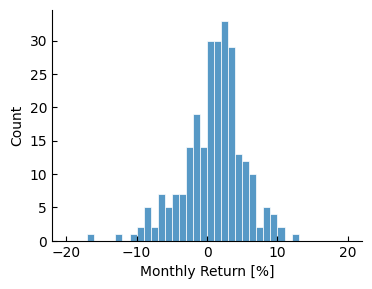

     CAGR [%]  Volatility [%]  Max Drawdown [%]  Sharpe 
--------------------------------------------------------
SPY   10.68        14.87            -50.78        0.65  


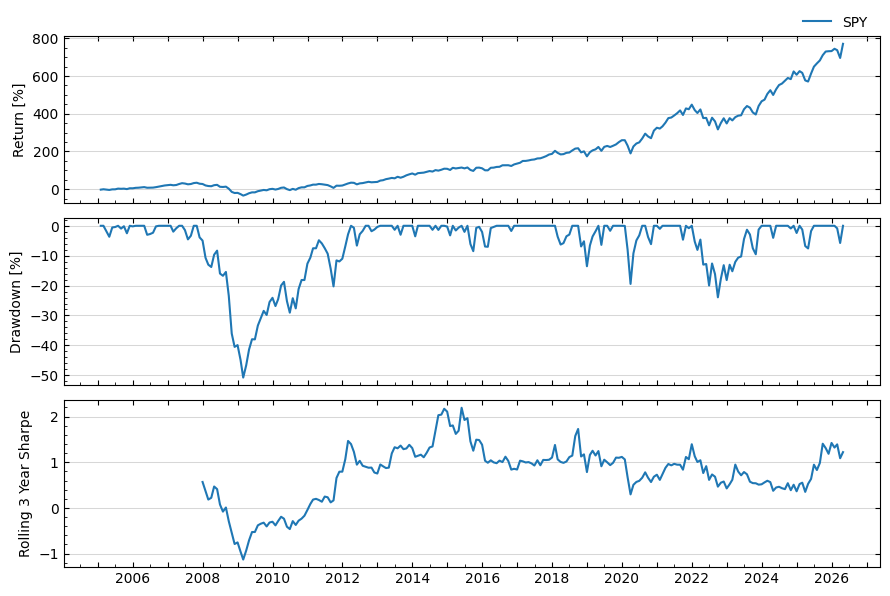

In [12]:
# plot SPY return distribution
fig, ax = plt.subplots(figsize=(4,3))
sns.histplot(returns['SPY'] * 100, edgecolor='w', bins=np.arange(-20,21,1))
sns.despine()
ax.set_xlabel('Monthly Return [%]')
plt.show()

# display performance summary
_ = performance_report(returns[['SPY']], risk_free_returns=rfr)

## Define a Universe of Assets
Can we do better by instead holding a more diversified portfolio of assets? Let's see.

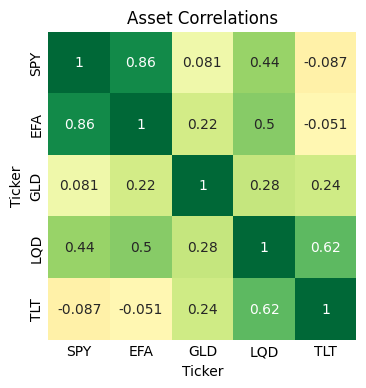

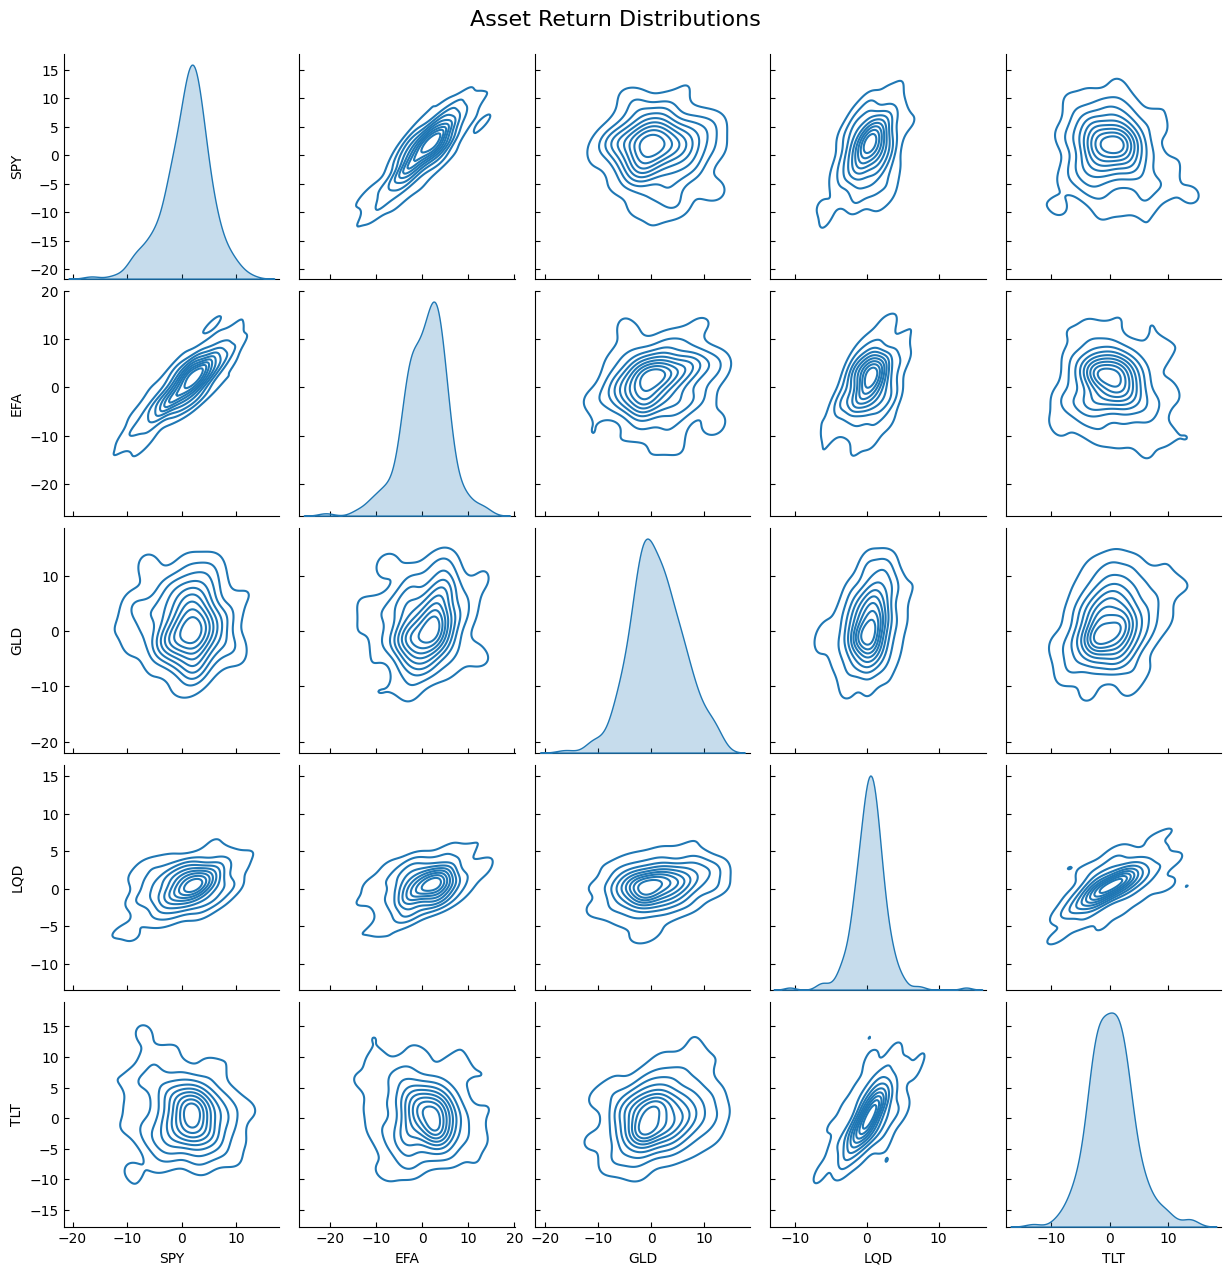

In [13]:
universe     = ['SPY', 'EFA', 'GLD', 'LQD', 'TLT']

# visualize asset correlations
corr_matrix = returns[universe].corr()

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(corr_matrix, vmax=1, vmin=-1, square=True, cbar=False, cmap='RdYlGn', annot=True)
ax.set_title('Asset Correlations')
ax.tick_params(axis='both', length=0)
plt.show()

# also visualize all the return distributions as a pairplot
g = sns.pairplot(returns[universe] * 100., kind='kde')
g.figure.suptitle('Asset Return Distributions', y=1.02)
plt.show()

### Do Correlations Hold Up in a Crisis?

The correlation matrix above is calculated over the full sample, and calm periods dominate that sample. But in a genuine equity sell-off - a broad flight-to-quality/liquidity crunch - most risk assets tend to get pulled down together, so correlations to equities can rise sharply right when diversification would matter most.

To check this, look at each asset's rolling correlation to SPY next to SPY's own drawdown - correlations should visibly climb during major equity drawdowns like 2008 and 2020, showing that "diversifying" assets diversify less exactly when it counts.

Also we can see an important regime change from ~2022 onwards where the correlations of long term treasuries (TLT) and corporate bonds (LQD) with US large cap equities (SPY) jump significantly higher to above 0.5. In this case they are no longer the "divesified" assets they were from 2005 to 2022. This is another a key observation because mean-variance optimization assumes that the covariance matrix is stable over time which it is clearly not!

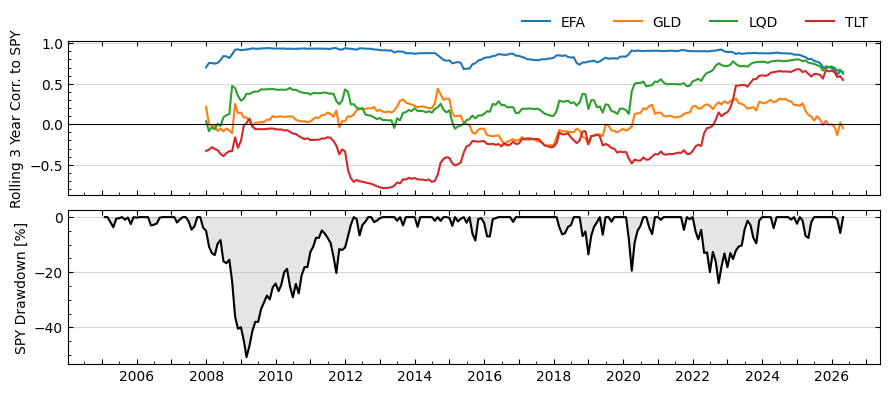

In [20]:
window       = 36
rolling_corr = get_rolling_correlation(returns[universe], returns['SPY'], window=window).drop(columns=['SPY'])
spy_drawdown = get_drawdown(returns[['SPY']])['SPY']

fig, axs = plt.subplots(nrows=2, figsize=(9, 4), sharex=True)

ax = axs[0]
for ticker in rolling_corr.columns:
    ax.plot(rolling_corr[ticker], label=ticker)
ax.axhline(0, color='k', linewidth=0.75)
ax.set_ylabel(f'Rolling 3 Year Corr. to SPY')
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.25), ncols=4, frameon=False)

ax = axs[1]
ax.plot(spy_drawdown * 100., color='k')
ax.fill_between(spy_drawdown.index, spy_drawdown * 100., 0, color='k', alpha=0.1)
ax.set_ylabel('SPY Drawdown [%]')

for ax in axs:
    set_date_ticks(ax)
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(top=True, bottom=True, left=True, right=True)
    ax.grid(axis='y', linewidth=0.75, alpha=0.5)

fig.tight_layout()
plt.show()

In [21]:
portfolio_name    = 'STOCK_BOND'
portfolio_weights = {'SPY' : 0.6,
                     'LQD' : 0.4,
                     }

if sum(list(portfolio_weights.values())) != 1:
    raise ValueError('Portfolio weights don\'t sum to 1!')

portfolio_returns = returns.mul(pd.Series(portfolio_weights)).sum(axis=1)
portfolio_returns = pd.DataFrame(portfolio_returns, columns=[portfolio_name])

stock_bond_df = returns[['SPY', 'LQD']].copy()
stock_bond_df = stock_bond_df.join(portfolio_returns)

## Efficient Frontier

Instead of picking portfolio weights by hand (like the 60/40 above), mean-variance optimization looks for the portfolio that minimizes risk (volatility) for a given level of expected return, across the full ETF universe. Sweeping across return levels traces out the *efficient frontier*.

The catch: mean-variance optimization needs a **forward-looking expected return** for each asset, not a historical one. We don't have a forecast, so as a stand-in we use each asset's historical sample mean return. This is a common simplification, but it's worth being upfront that it's a fairly noisy estimator (more below) - it's a stand-in for a real return forecast, not one itself.

In [22]:
mean_returns = get_annualized_mean_return(returns[universe])
cov_matrix   = returns[universe].cov() * 12
rf_rate      = rfr.mean() * 12

### How Noisy Are These Mean Return Estimates?

Roughly ~20 years of monthly data isn't much to pin down a mean return - the standard error of the estimate is often as large as the differences between assets' mean returns, which means the optimizer below is partly reacting to estimation noise, not real differences in expected return.

In [23]:
n_obs     = len(returns[universe])
std_error = (returns[universe].std() / np.sqrt(n_obs)) * 12  # annualized standard error of the mean

mean_estimate_df = pd.DataFrame({'Mean Return [%]' : mean_returns * 100,
                                 'Std Error [%]'    : std_error * 100,
                                 }).sort_values('Mean Return [%]', ascending=False)

print(mean_estimate_df.round(2))

        Mean Return [%]  Std Error [%]
Ticker                                
GLD               12.06           3.70
SPY               11.30           3.22
EFA                7.22           3.64
LQD                4.21           1.71
TLT                4.00           2.96


### Based on MOSEK Portfolio Optimization Cookbook

- Vector of asset weights $x$
- Vector of expected returns $\mu$
- Covariance matrix $\Sigma$

In portfolio stats, the 

Add mean geometric return instead of just mean arithmetic return. r_geo = r_arith - sigma^2 / 2

In [ ]:
gmv_weights    = solve_min_variance(mean_returns, cov_matrix)
sharpe_weights = solve_max_sharpe(mean_returns, cov_matrix, risk_free_rate=rf_rate)

gmv_return, gmv_vol       = get_portfolio_stats(gmv_weights, mean_returns, cov_matrix)
sharpe_return, sharpe_vol = get_portfolio_stats(sharpe_weights, mean_returns, cov_matrix)

print('Global Minimum Variance weights [%]')
print((gmv_weights * 100).round(1))
print()
print('Max Sharpe weights [%]')
print((sharpe_weights * 100).round(1))

In [ ]:
frontier = build_efficient_frontier(mean_returns, cov_matrix, n_points=50)

# random long-only portfolios, for visual context around the frontier
n_random       = 5000
random_weights = np.random.dirichlet(np.ones(len(universe)), size=n_random)
random_returns = random_weights @ mean_returns.values
random_vols    = np.sqrt(np.einsum('ij,jk,ik->i', random_weights, cov_matrix.values, random_weights))

### Plotting the Frontier

Individual assets, the efficient frontier, a cloud of random long-only portfolios (to show the frontier actually dominates arbitrary weightings), the Global Minimum Variance and Max Sharpe portfolios, the hand-built 60/40 SPY/LQD portfolio from earlier, and the Capital Market Line anchored at the BIL risk-free rate.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(random_vols * 100, random_returns * 100, s=4, alpha=0.15, color='0.6', label='Random portfolios')
ax.plot(frontier['volatility'] * 100, frontier['target_return'] * 100, color='k', label='Efficient frontier')

for ticker in universe:
    vol = np.sqrt(cov_matrix.loc[ticker, ticker]) * 100
    ret = mean_returns[ticker] * 100
    ax.scatter(vol, ret, color='tab:blue')
    ax.annotate(ticker, (vol, ret), textcoords='offset points', xytext=(4, 4), fontsize=8)

ax.scatter(gmv_vol * 100, gmv_return * 100, marker='*', s=250, color='tab:blue', zorder=5, label='Min Variance')
ax.scatter(sharpe_vol * 100, sharpe_return * 100, marker='*', s=250, color='tab:orange', zorder=5, label='Max Sharpe')

sixty_forty_weights          = pd.Series(portfolio_weights).reindex(universe).fillna(0.)
sixty_forty_return, sixty_forty_vol = get_portfolio_stats(sixty_forty_weights, mean_returns, cov_matrix)
ax.scatter(sixty_forty_vol * 100, sixty_forty_return * 100, marker='D', s=80, color='tab:green', zorder=5, label='60/40 SPY/LQD')

cml_x = np.array([0, sharpe_vol * 1.3])
cml_y = rf_rate + (sharpe_return - rf_rate) / sharpe_vol * cml_x
ax.plot(cml_x * 100, cml_y * 100, linestyle='--', color='gray', label='Capital Market Line')

ax.set_xlabel('Annualized Volatility [%]')
ax.set_ylabel('Annualized Return [%]')
ax.legend(loc='lower right', frameon=False)

fig.tight_layout()
plt.show()

### Aside: Covariance Shrinkage

The sample covariance matrix above is itself a noisy estimate, especially with several correlated assets and a limited history. A common, cheap fix is to shrink it toward a more structured target (Ledoit-Wolf shrinkage) - this trades off a bit of bias for a meaningful reduction in estimation error, which tends to make the Min Variance portfolio less sensitive to sampling noise.

In [ ]:
from sklearn.covariance import LedoitWolf

shrunk_cov = pd.DataFrame(LedoitWolf().fit(returns[universe]).covariance_ * 12,
                          index=universe, columns=universe)

gmv_weights_shrunk        = solve_min_variance(mean_returns, shrunk_cov)
gmv_return_shrunk, gmv_vol_shrunk = get_portfolio_stats(gmv_weights_shrunk, mean_returns, shrunk_cov)

comparison_df = pd.DataFrame({'Sample Cov [%]' : gmv_weights * 100,
                              'Shrunk Cov [%]'  : gmv_weights_shrunk * 100,
                              }).round(1)

print(comparison_df)
print()
print(f'Sample cov GMV volatility: {gmv_vol * 100:.2f}%')
print(f'Shrunk cov GMV volatility: {gmv_vol_shrunk * 100:.2f}%')